===== 训练 RNN =====
RNN | Epoch 10 | Loss 0.0415 | Test MSE 0.2718
RNN | Epoch 20 | Loss 0.0072 | Test MSE 0.2978
RNN | Epoch 30 | Loss 0.0063 | Test MSE 0.2822
RNN | Epoch 40 | Loss 0.0058 | Test MSE 0.2539


C:\Users\lx\AppData\Local\Temp\ipykernel_23284\4003891898.py:98: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_23284\4003891898.py:98: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_23284\4003891898.py:98: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_23284\4003891898.py:98: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_23284\4003891898.py:98: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_23284\4003891898.py:98: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEO

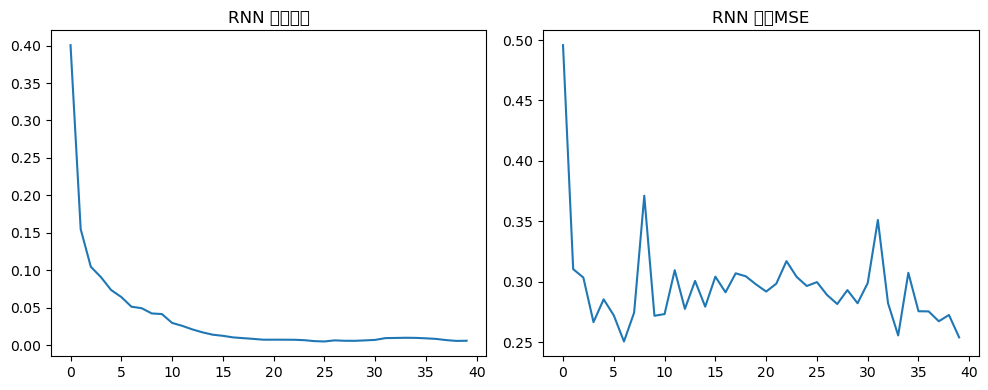


===== 训练 GRU =====
GRU | Epoch 10 | Loss 0.0366 | Test MSE 0.4167
GRU | Epoch 20 | Loss 0.0164 | Test MSE 0.4338
GRU | Epoch 30 | Loss 0.0094 | Test MSE 0.4245
GRU | Epoch 40 | Loss 0.0034 | Test MSE 0.3912


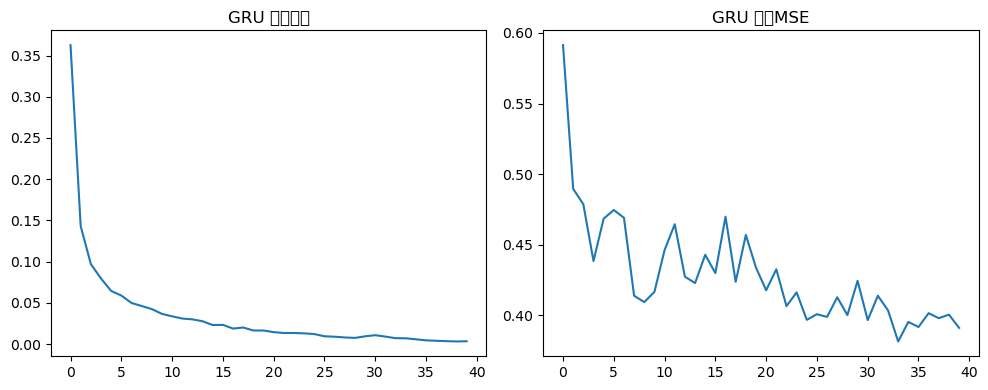


===== 训练 LSTM =====
LSTM | Epoch 10 | Loss 0.0343 | Test MSE 0.5173
LSTM | Epoch 20 | Loss 0.0153 | Test MSE 0.5245
LSTM | Epoch 30 | Loss 0.0112 | Test MSE 0.5490
LSTM | Epoch 40 | Loss 0.0081 | Test MSE 0.4913


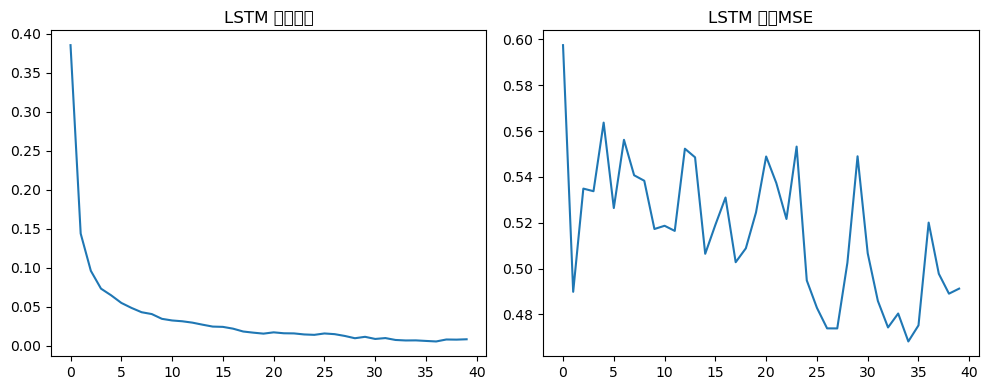

([0.38511777525648067,
  0.1435866674425405,
  0.09585707692788281,
  0.07299839103714041,
  0.06444164958500534,
  0.054725969927983543,
  0.048311123709886446,
  0.04276956807514396,
  0.04041597970821168,
  0.0342930891046967,
  0.032208108471347655,
  0.031181680303442916,
  0.029419875088566486,
  0.026797073081545872,
  0.024366178143974564,
  0.023997727465397176,
  0.021711282684134508,
  0.018056816011325482,
  0.01657760056555955,
  0.01532946722667425,
  0.01698212549004943,
  0.01580153725648282,
  0.015618147478020246,
  0.014292001344024315,
  0.013770635244052072,
  0.01554379765576589,
  0.014665405483865137,
  0.012380848651529726,
  0.009435613895980043,
  0.01124888780919852,
  0.008514319777215293,
  0.009641805565446068,
  0.007210057805540091,
  0.006575913008285362,
  0.00667858112992189,
  0.005971819365294565,
  0.005295306474072944,
  0.007820933356607726,
  0.007637615644569517,
  0.008102005725692309],
 [0.5975127816200256,
  0.48985975980758667,
  0.5349058

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ===================== 1. 读取与处理数据 =====================
df = pd.read_csv("../data/volume-11kw.csv")
data = df.drop(columns=["time"]).values
data = np.nan_to_num(data)

# ===================== 2. 超参数 =====================
seq_len = 12
batch_size = 32
hidden_size = 64
num_layers = 2
epochs = 40
lr = 0.001
input_size = data.shape[1]

# ===================== 3. 标准化 =====================
mean = data.mean(axis=0)
std = data.std(axis=0)
data = (data - mean) / (std + 1e-8)

# ===================== 4. 构建时序样本 =====================
def make_data(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 0])
    return np.array(X), np.array(y)

X, y = make_data(data, seq_len)

# ===================== 5. 划分训练/测试集 =====================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ===================== 6. 转为张量 =====================
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ===================== 7. 数据加载器 =====================
class SensorDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_loader = DataLoader(SensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

# ===================== 8. 训练函数 =====================
def train_model(model, model_name):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loss = []
    test_mse = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for bx, by in train_loader:
            pred = model(bx)
            loss = criterion(pred, by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        train_loss.append(avg_loss)

        model.eval()
        with torch.no_grad():
            pred_test = model(X_test)
            mse = criterion(pred_test, y_test).item()
        test_mse.append(mse)

        if (epoch+1) % 10 == 0:
            print(f"{model_name} | Epoch {epoch+1:2d} | Loss {avg_loss:.4f} | Test MSE {mse:.4f}")

    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.plot(train_loss)
    plt.title(f"{model_name} 训练损失")
    plt.subplot(122)
    plt.plot(test_mse)
    plt.title(f"{model_name} 测试MSE")
    plt.tight_layout()
    plt.show()
    return train_loss, test_mse

# ===================== 9. 模型定义 =====================
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# ===================== 10. 开始训练 =====================
print("===== 训练 RNN =====")
train_model(RNNModel(), "RNN")

print("\n===== 训练 GRU =====")
train_model(GRUModel(), "GRU")

print("\n===== 训练 LSTM =====")
train_model(LSTMModel(), "LSTM")